# Musterlösung – Aufgabenblatt 3
## Eindimensionale Analysis – Differentialrechnung 3
### Vektorfunktionen, Raumkurven, Frenet-Serret-Apparat

---

## Mathematischer Hintergrund

Eine **Raumkurve** ist eine differenzierbare Abbildung $\mathbf{R}: \mathbb{R} \to \mathbb{R}^3$. Jeder Punkt der Kurve trägt ein lokales Koordinatensystem – das **Frenet-Serret-Dreibein** $\{\mathbf{T}, \mathbf{N}, \mathbf{B}\}$.

### Bogenlänge und Einheitstangente
$$\frac{ds}{dt} = \left\|\frac{d\mathbf{R}}{dt}\right\|, \qquad \mathbf{T} = \frac{d\mathbf{R}/dt}{\|d\mathbf{R}/dt\|}$$

### Frenet-Serret-Dreibein

| Symbol | Name | Definition |
|--------|------|------------|
| $\mathbf{T}$ | Einheitstangente | Zeigt in Kurvenrichtung |
| $\mathbf{N}$ | Hauptnormale | $\mathbf{N} = \dfrac{1}{\kappa}\dfrac{d\mathbf{T}}{ds}$, zeigt zum Krümmungsmittelpunkt |
| $\mathbf{B}$ | Binormale | $\mathbf{B} = \mathbf{T} \times \mathbf{N}$, senkrecht zur Schmiegebene |

### Frenet-Serret-Formeln
$$\frac{d\mathbf{T}}{ds} = \kappa\,\mathbf{N}, \qquad \frac{d\mathbf{N}}{ds} = -\kappa\,\mathbf{T} + \tau\,\mathbf{B}, \qquad \frac{d\mathbf{B}}{ds} = -\tau\,\mathbf{N}$$

- **Krümmung** $\kappa \geq 0$: Wie stark biegt sich die Kurve? Krümmungsradius $R = 1/\kappa$.
- **Torsion** $\tau$: Wie stark windet sich die Kurve aus der Schmiegebene heraus? Für ebene Kurven: $\tau = 0$.

In [1]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'lines.linewidth': 2})

t = symbols('t', real=True, positive=True)
init_printing(use_latex='mathjax')
print("Setup abgeschlossen.")
try:
    from IPython.display import display
except ImportError:
    display = print

Setup abgeschlossen.


---
### Aufgabe 1

**Gegeben:** $f(t)=\begin{pmatrix}\sin t \\ \cos t \\ t\end{pmatrix}$

**Gesucht:** Plot der Kurve sowie $\dfrac{df}{dt}$, $\dfrac{d^2f}{dt^2}$, $\left\|\dfrac{df}{dt}\right\|$, $\left\|\dfrac{d^2f}{dt^2}\right\|$

> **Geometrie:** Die Kurve beschreibt eine **Helix** (Schraubenlinie): In der $xy$-Ebene bewegt sich der Punkt auf dem Einheitskreis ($\sin^2 t + \cos^2 t = 1$), während $z = t$ gleichmäßig anwächst.

**Schritt 1:** Komponentenweise differenzieren:
$$\frac{df}{dt} = \begin{pmatrix}\frac{d}{dt}\sin t \\ \frac{d}{dt}\cos t \\ \frac{d}{dt}t\end{pmatrix} = \begin{pmatrix}\cos t \\ -\sin t \\ 1\end{pmatrix}$$

**Schritt 2:** Zweite Ableitung:
$$\frac{d^2f}{dt^2} = \begin{pmatrix}-\sin t \\ -\cos t \\ 0\end{pmatrix}$$

**Schritt 3:** Beträge (mit $\sin^2 t + \cos^2 t = 1$):
$$\left\|\frac{df}{dt}\right\| = \sqrt{\cos^2 t + \sin^2 t + 1} = \sqrt{2}, \qquad \left\|\frac{d^2f}{dt^2}\right\| = \sqrt{\sin^2 t + \cos^2 t} = 1$$

> **Interpretation:** Beide Beträge sind **konstant** – die Helix wird gleichmäßig parametrisiert. Die Beschleunigung (Betrag 1) zeigt stets radial zur $z$-Achse (zentripetal).

In [2]:
f1   = Matrix([sin(t), cos(t), t])
df1  = diff(f1, t)
d2f1 = diff(f1, t, 2)

print("df/dt =")
display(df1)
print("d2f/dt2 =")
display(d2f1)
print("||df/dt||  =", trigsimp(df1.norm()))
print("||d2f/dt2||=", trigsimp(d2f1.norm()))

df/dt =


⎡cos(t) ⎤
⎢       ⎥
⎢-sin(t)⎥
⎢       ⎥
⎣   1   ⎦

d2f/dt2 =


⎡-sin(t)⎤
⎢       ⎥
⎢-cos(t)⎥
⎢       ⎥
⎣   0   ⎦

||df/dt||  = sqrt(2)
||d2f/dt2||= 1


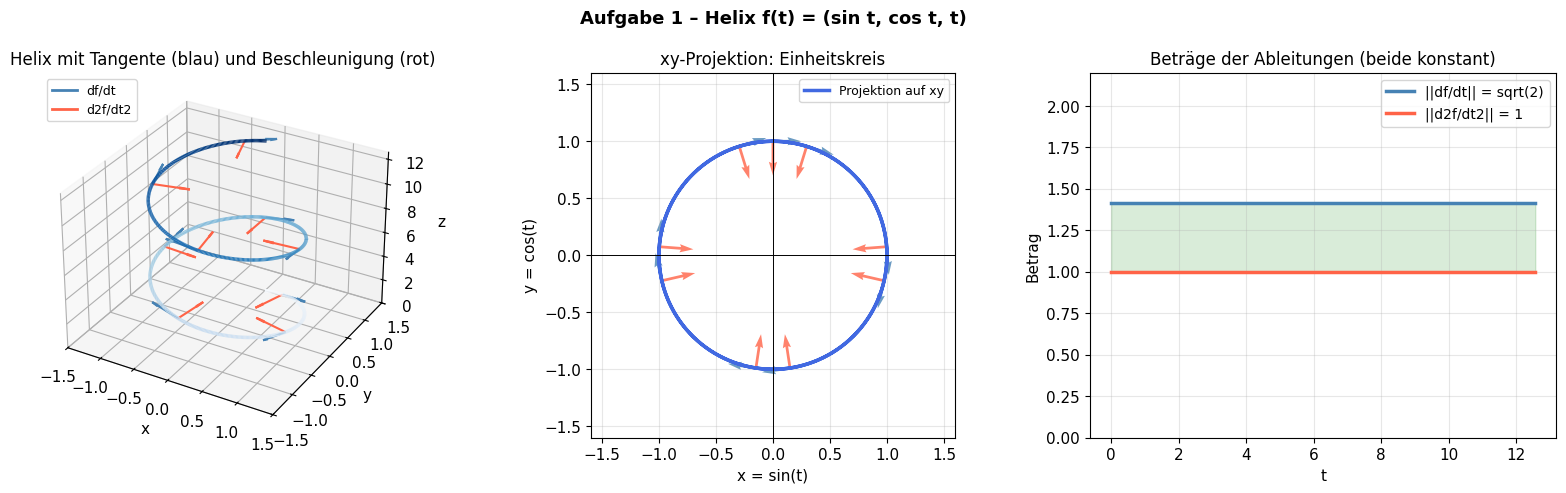

In [3]:
# ── Visualisierung Aufgabe 1 ─────────────────────────────────────────────────
t_v = np.linspace(0, 4*np.pi, 800)
x1, y1, z1 = np.sin(t_v), np.cos(t_v), t_v

t_pts = np.linspace(0.3, 4*np.pi-0.3, 9)
xp, yp, zp = np.sin(t_pts), np.cos(t_pts), t_pts
Tx, Ty, Tz = np.cos(t_pts), -np.sin(t_pts), np.ones_like(t_pts)   # df/dt (unormiert)
Ax, Ay, Az = -np.sin(t_pts), -np.cos(t_pts), np.zeros_like(t_pts) # d2f/dt2

fig = plt.figure(figsize=(16, 5))

# Panel 1: 3D-Helix mit Tangenten und Beschleunigung
ax1 = fig.add_subplot(131, projection='3d')
pts = np.array([x1,y1,z1]).T.reshape(-1,1,3)
segs = np.concatenate([pts[:-1],pts[1:]], axis=1)
lc = Line3DCollection(segs, cmap='Blues', linewidth=2.5)
lc.set_array(t_v[:-1])
ax1.add_collection3d(lc)
sc = 0.6/np.sqrt(2)
for i in range(len(t_pts)):
    ax1.quiver(xp[i],yp[i],zp[i], Tx[i]*sc,Ty[i]*sc,Tz[i]*sc,
               color='steelblue', arrow_length_ratio=0.3, lw=1.5)
    ax1.quiver(xp[i],yp[i],zp[i], Ax[i]*0.5,Ay[i]*0.5,Az[i]*0.5,
               color='tomato', arrow_length_ratio=0.3, lw=1.5)
ax1.set_xlim(-1.5,1.5); ax1.set_ylim(-1.5,1.5); ax1.set_zlim(0,4*np.pi)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("Helix mit Tangente (blau) und Beschleunigung (rot)")
handles = [Line2D([0],[0],color='steelblue',lw=2,label="df/dt"),
           Line2D([0],[0],color='tomato',   lw=2,label="d2f/dt2")]
ax1.legend(handles=handles, fontsize=9, loc='upper left')

# Panel 2: xy-Projektion (Einheitskreis)
ax2 = fig.add_subplot(132)
ax2.plot(x1, y1, color='royalblue', lw=2.5, label="Projektion auf xy")
ax2.add_patch(plt.Circle((0,0),1,color='gray',fill=False,ls='--',alpha=0.4))
sc2 = 0.35/np.sqrt(2)
ax2.quiver(xp, yp, Tx*sc2, Ty*sc2, color='steelblue', scale=1,
           scale_units='xy', angles='xy', alpha=0.8)
ax2.quiver(xp, yp, Ax*0.3, Ay*0.3, color='tomato', scale=1,
           scale_units='xy', angles='xy', alpha=0.8)
ax2.set_aspect('equal')
ax2.set_xlim(-1.6,1.6); ax2.set_ylim(-1.6,1.6)
ax2.axhline(0,color='k',lw=0.7); ax2.axvline(0,color='k',lw=0.7)
ax2.grid(True, alpha=0.3)
ax2.set_title("xy-Projektion: Einheitskreis")
ax2.set_xlabel("x = sin(t)"); ax2.set_ylabel("y = cos(t)")
ax2.legend(fontsize=9)

# Panel 3: Beträge als Funktion von t
ax3 = fig.add_subplot(133)
norm1 = np.full_like(t_v, np.sqrt(2))
norm2 = np.ones_like(t_v)
ax3.plot(t_v, norm1, color='steelblue', lw=2.5, label="||df/dt|| = sqrt(2)")
ax3.plot(t_v, norm2, color='tomato',    lw=2.5, label="||d2f/dt2|| = 1")
ax3.fill_between(t_v, norm2, norm1, alpha=0.15, color='green')
ax3.set_xlabel("t"); ax3.set_ylabel("Betrag")
ax3.set_ylim(0, 2.2)
ax3.set_title("Beträge der Ableitungen (beide konstant)")
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

plt.suptitle("Aufgabe 1 – Helix f(t) = (sin t, cos t, t)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Aufgabe 2

**Gegeben:** $f(t)=\begin{pmatrix}e^{-t} \\ 2\cos 3t \\ 2\sin 3t\end{pmatrix}$

**a)** Geschwindigkeit $\mathbf{v}(t)$ und Beschleunigung $\mathbf{a}(t)$

**b)** Beträge $\|\mathbf{v}(0)\|$ und $\|\mathbf{a}(0)\|$

> **Geometrie:** Die $y$- und $z$-Komponenten beschreiben eine Kreisbewegung (Radius 2, Winkelgeschwindigkeit 3). Die $x$-Komponente fällt exponentiell ab – das Teilchen **schraubt sich spiralförmig** auf den Kreis in der $yz$-Ebene zu.

**Schritt 1:** Komponentenweise differenzieren (Kettenregel):
$$\mathbf{v}(t) = \frac{df}{dt} = \begin{pmatrix}-e^{-t} \\ -6\sin 3t \\ 6\cos 3t\end{pmatrix}$$

$$\mathbf{a}(t) = \frac{d^2f}{dt^2} = \begin{pmatrix}e^{-t} \\ -18\cos 3t \\ -18\sin 3t\end{pmatrix}$$

**Schritt 2:** Bei $t=0$ einsetzen ($e^0=1$, $\cos 0=1$, $\sin 0=0$):
$$\mathbf{v}(0) = \begin{pmatrix}-1\\0\\6\end{pmatrix} \Rightarrow \|\mathbf{v}(0)\| = \sqrt{1+0+36} = \sqrt{37}$$

$$\mathbf{a}(0) = \begin{pmatrix}1\\-18\\0\end{pmatrix} \Rightarrow \|\mathbf{a}(0)\| = \sqrt{1+324+0} = \sqrt{325} = 5\sqrt{13}$$

In [4]:
f2 = Matrix([exp(-t), 2*cos(3*t), 2*sin(3*t)])
v2 = diff(f2, t)
a2 = diff(f2, t, 2)

print("a) Geschwindigkeit v(t):")
display(v2)
print("a) Beschleunigung a(t):")
display(a2)

v0 = v2.subs(t, 0);  a0 = a2.subs(t, 0)
print("b) v(0) =", v0.T, "  ||v(0)|| =", simplify(v0.norm()))
print("   a(0) =", a0.T, "  ||a(0)|| =", simplify(a0.norm()))

a) Geschwindigkeit v(t):


⎡     -t    ⎤
⎢   -ℯ      ⎥
⎢           ⎥
⎢-6⋅sin(3⋅t)⎥
⎢           ⎥
⎣6⋅cos(3⋅t) ⎦

a) Beschleunigung a(t):


⎡     -t     ⎤
⎢    ℯ       ⎥
⎢            ⎥
⎢-18⋅cos(3⋅t)⎥
⎢            ⎥
⎣-18⋅sin(3⋅t)⎦

b) v(0) = Matrix([[-1, 0, 6]])   ||v(0)|| = sqrt(37)
   a(0) = Matrix([[1, -18, 0]])   ||a(0)|| = 5*sqrt(13)


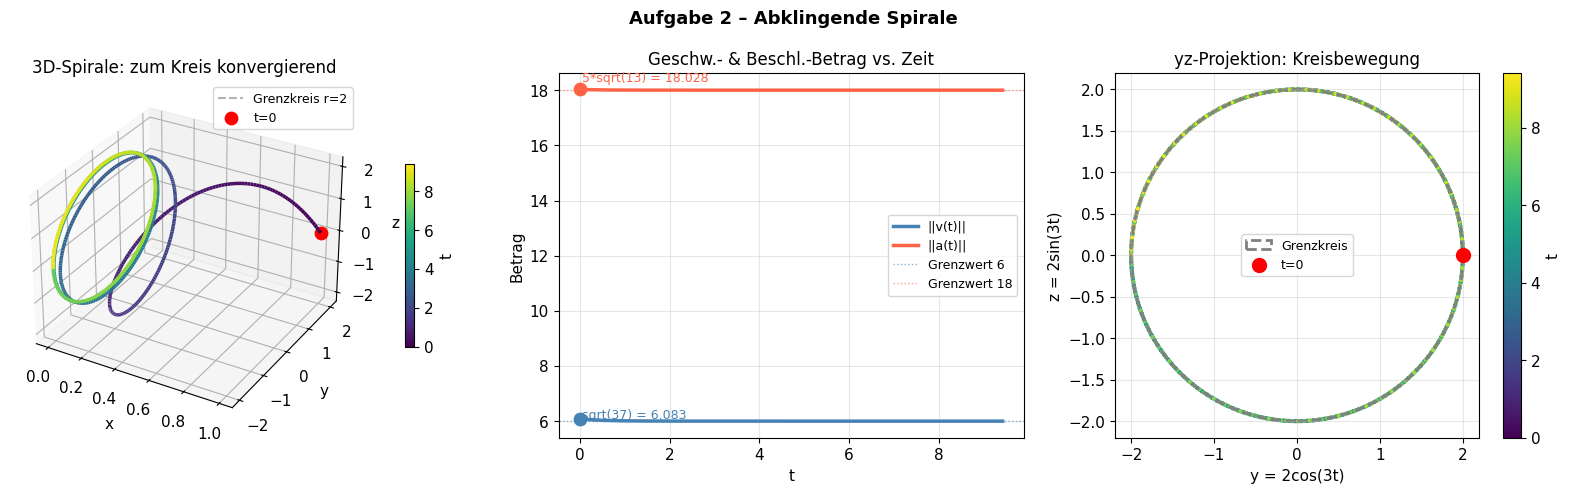

In [5]:
# ── Visualisierung Aufgabe 2 ─────────────────────────────────────────────────
t_v = np.linspace(0, 3*np.pi, 800)
x2 = np.exp(-t_v)
y2 = 2*np.cos(3*t_v)
z2 = 2*np.sin(3*t_v)

speed2 = np.sqrt(np.exp(-2*t_v) + 36)          # ||v||
acc2   = np.sqrt(np.exp(-2*t_v) + 324)          # ||a||

fig = plt.figure(figsize=(16, 5))

# Panel 1: 3D-Spirale
ax1 = fig.add_subplot(131, projection='3d')
pts = np.array([x2,y2,z2]).T.reshape(-1,1,3)
segs = np.concatenate([pts[:-1],pts[1:]], axis=1)
lc = Line3DCollection(segs, cmap='viridis', linewidth=2.5)
lc.set_array(t_v[:-1])
ax1.add_collection3d(lc)
# Grenzkreis
th = np.linspace(0,2*np.pi,200)
ax1.plot(np.zeros(200), 2*np.cos(th), 2*np.sin(th),
         'gray', lw=1.5, ls='--', alpha=0.6, label="Grenzkreis r=2")
ax1.scatter([1],[2],[0], color='red', s=80, zorder=5, label='t=0')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("3D-Spirale: zum Kreis konvergierend")
ax1.legend(fontsize=9)
fig.colorbar(lc, ax=ax1, pad=0.1, shrink=0.5, label='t')

# Panel 2: ||v|| und ||a|| über t
ax2 = fig.add_subplot(132)
ax2.plot(t_v, speed2, color='steelblue', lw=2.5, label="||v(t)||")
ax2.plot(t_v, acc2,   color='tomato',    lw=2.5, label="||a(t)||")
ax2.scatter([0],[np.sqrt(37)],  color='steelblue', s=80, zorder=5)
ax2.scatter([0],[5*np.sqrt(13)],color='tomato',    s=80, zorder=5)
ax2.annotate(f"sqrt(37) = {np.sqrt(37):.3f}",
             xy=(0.05, np.sqrt(37)), fontsize=9, color='steelblue')
ax2.annotate(f"5*sqrt(13) = {5*np.sqrt(13):.3f}",
             xy=(0.05, 5*np.sqrt(13)+0.3), fontsize=9, color='tomato')
ax2.axhline(6, color='steelblue', lw=1, ls=':', alpha=0.6, label="Grenzwert 6")
ax2.axhline(18, color='tomato',   lw=1, ls=':', alpha=0.6, label="Grenzwert 18")
ax2.set_xlabel('t'); ax2.set_ylabel('Betrag')
ax2.set_title("Geschw.- & Beschl.-Betrag vs. Zeit")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Panel 3: yz-Projektion mit t-Farbskala
ax3 = fig.add_subplot(133)
sc = ax3.scatter(y2, z2, c=t_v, cmap='viridis', s=4)
ax3.add_patch(plt.Circle((0,0), 2, color='gray', fill=False,
                          ls='--', lw=2, label='Grenzkreis'))
ax3.scatter([2],[0], color='red', s=100, zorder=5, label='t=0')
ax3.set_aspect('equal')
ax3.set_xlabel("y = 2cos(3t)"); ax3.set_ylabel("z = 2sin(3t)")
ax3.set_title("yz-Projektion: Kreisbewegung")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax3, label='t')

plt.suptitle("Aufgabe 2 – Abklingende Spirale", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Aufgaben 3 & 4 – Schraubenlinie

**Gegeben:** $\mathbf{R}=\begin{pmatrix}3\cos t \\ 3\sin t \\ 4t\end{pmatrix}$ (Radius 3, Steigung 4)

**Aufgabe 3:** (a) Einheitstangente $\mathbf{T}$, (b) Krümmung $\kappa$, (c) Hauptnormale $\mathbf{N}$

**Aufgabe 4:** (a) Binormale $\mathbf{B}$, (b) Torsion $\tau$

**Vorbereitng – Bogenlängenableitung:**
$$\frac{d\mathbf{R}}{dt} = \begin{pmatrix}-3\sin t \\ 3\cos t \\ 4\end{pmatrix}, \qquad \frac{ds}{dt} = \sqrt{9\sin^2 t + 9\cos^2 t + 16} = \sqrt{9+16} = 5$$

Die Schraubenlinie hat **konstante Geschwindigkeit** 5 – sie ist gleichmäßig parametrisiert.

**Aufgabe 3a – Einheitstangente:**
$$\mathbf{T} = \frac{d\mathbf{R}/dt}{\|d\mathbf{R}/dt\|} = \frac{1}{5}\begin{pmatrix}-3\sin t \\ 3\cos t \\ 4\end{pmatrix}$$

**Aufgabe 3b – Krümmung:** Mit $\dfrac{d\mathbf{T}}{ds} = \dfrac{1}{ds/dt}\dfrac{d\mathbf{T}}{dt} = \dfrac{1}{5}\cdot\dfrac{1}{5}\begin{pmatrix}-3\cos t \\ -3\sin t \\ 0\end{pmatrix}$:

$$\kappa = \left\|\frac{d\mathbf{T}}{ds}\right\| = \frac{1}{25}\sqrt{9\cos^2 t + 9\sin^2 t} = \frac{3}{25}$$

**Aufgabe 3c – Hauptnormale:**
$$\mathbf{N} = \frac{1}{\kappa}\frac{d\mathbf{T}}{ds} = \frac{25}{3}\cdot\frac{1}{25}\begin{pmatrix}-3\cos t\\-3\sin t\\0\end{pmatrix} = \begin{pmatrix}-\cos t\\-\sin t\\0\end{pmatrix}$$

$\mathbf{N}$ zeigt **radial zur Achse** – der Normalenvektor einer Helix ist immer horizontal.

**Aufgabe 4a – Binormale:**
$$\mathbf{B} = \mathbf{T}\times\mathbf{N} = \frac{1}{5}\begin{pmatrix}4\sin t \\ -4\cos t \\ 3\end{pmatrix}$$

**Aufgabe 4b – Torsion:** Mit $\dfrac{d\mathbf{B}}{ds} = \dfrac{4}{25}\begin{pmatrix}\cos t\\\sin t\\0\end{pmatrix} = -\dfrac{4}{25}\mathbf{N}$:
$$\boxed{\tau = \frac{4}{25}}$$

> **Satz von Lancret:** Für eine reguläre Helix sind $\kappa$ und $\tau$ **konstant**. Hier: $\kappa = 3/25$, $\tau = 4/25$.

In [6]:
R3    = Matrix([3*cos(t), 3*sin(t), 4*t])
dR3   = diff(R3, t)
dsdt3 = simplify(dR3.norm())
T3    = simplify(dR3 / dsdt3)
dT3ds = simplify(diff(T3,t) / dsdt3)
kappa3= simplify(dT3ds.norm())
N3    = simplify(dT3ds / kappa3)
B3    = simplify(T3.cross(N3))
dBds3 = simplify(diff(B3,t) / dsdt3)
tau3  = simplify(-dBds3.dot(N3))

print("ds/dt =", dsdt3)
print("T =");     display(T3)
print("kappa =",  kappa3, "  Kruemmungsradius R = 1/kappa =", Rational(25,3))
print("N =");     display(N3)
print("B =");     display(B3)
print("tau =",    tau3)

print("\n── Frenet-Serret Verifikation ──")
print("||T|| =", trigsimp(T3.norm()))
print("||N|| =", trigsimp(N3.norm()))
print("||B|| =", trigsimp(B3.norm()))
print("T·N =",   trigsimp(T3.dot(N3)))
print("dT/ds - kappa*N = 0:", trigsimp(dT3ds - kappa3*N3) == zeros(3,1))
print("dB/ds + tau*N  = 0:", trigsimp(dBds3 + tau3*N3)  == zeros(3,1))

ds/dt = 5
T =


⎡-3⋅sin(t) ⎤
⎢──────────⎥
⎢    5     ⎥
⎢          ⎥
⎢ 3⋅cos(t) ⎥
⎢ ──────── ⎥
⎢    5     ⎥
⎢          ⎥
⎣   4/5    ⎦

kappa = 3/25   Kruemmungsradius R = 1/kappa = 25/3
N =


⎡-cos(t)⎤
⎢       ⎥
⎢-sin(t)⎥
⎢       ⎥
⎣   0   ⎦

B =


⎡ 4⋅sin(t) ⎤
⎢ ──────── ⎥
⎢    5     ⎥
⎢          ⎥
⎢-4⋅cos(t) ⎥
⎢──────────⎥
⎢    5     ⎥
⎢          ⎥
⎣   3/5    ⎦

tau = 4/25

── Frenet-Serret Verifikation ──
||T|| = 1
||N|| = 1
||B|| = 1
T·N = 0
dT/ds - kappa*N = 0: True
dB/ds + tau*N  = 0: True


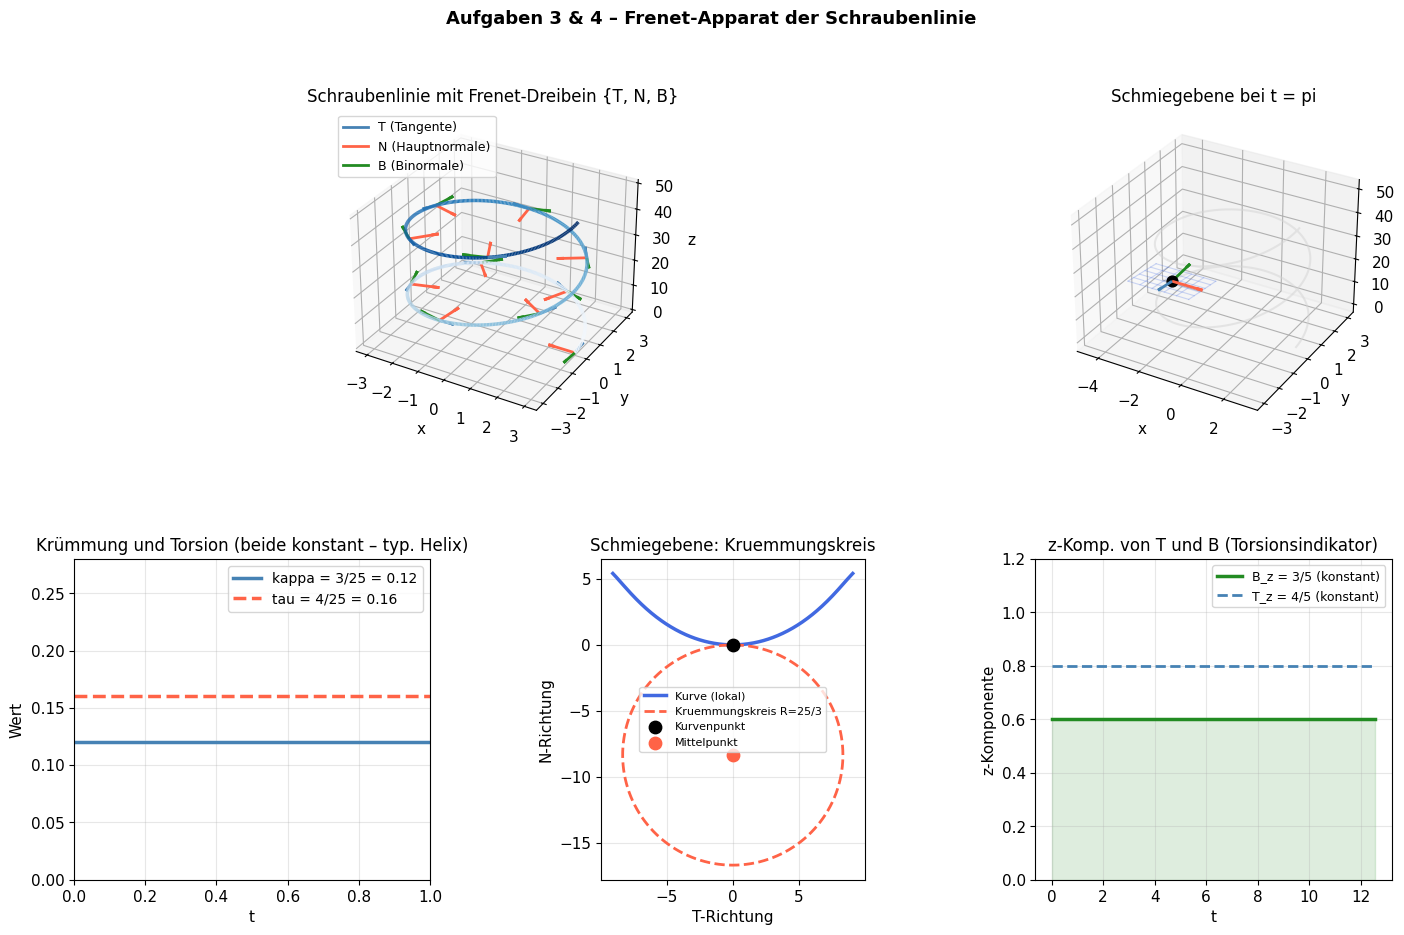

In [7]:
# ── Visualisierung Aufgaben 3 & 4 ────────────────────────────────────────────
t_v = np.linspace(0, 4*np.pi, 800)
X3 = 3*np.cos(t_v); Y3 = 3*np.sin(t_v); Z3 = 4*t_v

def frenet3(tp):
    T = np.array([-3*np.sin(tp), 3*np.cos(tp), 4.0]) / 5
    N = np.array([-np.cos(tp), -np.sin(tp), 0.0])
    B = np.array([4*np.sin(tp)/5, -4*np.cos(tp)/5, 3/5])
    return T, N, B

t_pts = np.linspace(0, 4*np.pi, 11, endpoint=False)

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: 3D-Kurve mit Frenet-Dreibein ────────────────────────────────────
ax1 = fig.add_subplot(gs[0,:2], projection='3d')
pts = np.array([X3,Y3,Z3]).T.reshape(-1,1,3)
segs = np.concatenate([pts[:-1],pts[1:]], axis=1)
lc = Line3DCollection(segs, cmap='Blues', linewidth=2.5)
lc.set_array(t_v[:-1])
ax1.add_collection3d(lc)
sc = 1.0
for tp in t_pts:
    p = np.array([3*np.cos(tp), 3*np.sin(tp), 4*tp])
    T, N, B = frenet3(tp)
    ax1.quiver(*p, *(T*sc), color='steelblue',    arrow_length_ratio=0.25, lw=2)
    ax1.quiver(*p, *(N*sc), color='tomato',        arrow_length_ratio=0.25, lw=2)
    ax1.quiver(*p, *(B*sc), color='forestgreen',   arrow_length_ratio=0.25, lw=2)
handles = [Line2D([0],[0],color='steelblue',  lw=2,label='T (Tangente)'),
           Line2D([0],[0],color='tomato',      lw=2,label='N (Hauptnormale)'),
           Line2D([0],[0],color='forestgreen', lw=2,label='B (Binormale)')]
ax1.legend(handles=handles, loc='upper left', fontsize=9)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("Schraubenlinie mit Frenet-Dreibein {T, N, B}")

# ── Panel 2: Schmiegebene an einem Punkt ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0,2], projection='3d')
tp0 = np.pi
p0 = np.array([3*np.cos(tp0), 3*np.sin(tp0), 4*tp0])
T0, N0, B0 = frenet3(tp0)
ax2.plot(X3, Y3, Z3, color='lightgray', lw=1.5, alpha=0.5)
u_r = np.linspace(-1.5, 1.5, 6)
for u in u_r:
    pts_line = [p0 + u*T0 + v*N0 for v in u_r]
    xs,ys,zs = zip(*pts_line)
    ax2.plot(xs,ys,zs, color='royalblue', alpha=0.25, lw=0.8)
for v in u_r:
    pts_line = [p0 + u*T0 + v*N0 for u in u_r]
    xs,ys,zs = zip(*pts_line)
    ax2.plot(xs,ys,zs, color='royalblue', alpha=0.25, lw=0.8)
ax2.quiver(*p0, *(T0*1.5), color='steelblue',   arrow_length_ratio=0.2, lw=2)
ax2.quiver(*p0, *(N0*1.5), color='tomato',       arrow_length_ratio=0.2, lw=2)
ax2.quiver(*p0, *(B0*1.5), color='forestgreen',  arrow_length_ratio=0.2, lw=2)
ax2.scatter(*p0, color='black', s=60, zorder=5)
ax2.set_title("Schmiegebene bei t = pi")
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

# ── Panel 3: kappa und tau ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.axhline(3/25, color='steelblue', lw=2.5, label="kappa = 3/25 = 0.12")
ax3.axhline(4/25, color='tomato',    lw=2.5, ls='--', label="tau = 4/25 = 0.16")
ax3.set_ylim(0, 0.28)
ax3.set_xlabel('t'); ax3.set_ylabel('Wert')
ax3.set_title("Krümmung und Torsion (beide konstant – typ. Helix)")
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

# ── Panel 4: Krümmungskreis in der Schmiegebene ───────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
tp_c = np.pi
p_c = np.array([3*np.cos(tp_c), 3*np.sin(tp_c), 4*tp_c])
T_c, N_c, B_c = frenet3(tp_c)
t_loc = np.linspace(tp_c-2.5, tp_c+2.5, 400)
curve_loc = np.array([[3*np.cos(tl), 3*np.sin(tl), 4*tl] for tl in t_loc])
proj_T = (curve_loc - p_c) @ T_c
proj_N = (curve_loc - p_c) @ N_c
ax4.plot(proj_T, proj_N, 'royalblue', lw=2.5, label='Kurve (lokal)')
R_curv = 25/3
theta_k = np.linspace(0,2*np.pi,300)
ax4.plot(R_curv*np.cos(theta_k), R_curv*np.sin(theta_k)-R_curv,
         'tomato', lw=2, ls='--', label=f'Kruemmungskreis R=25/3')
ax4.scatter([0],[0], color='black', s=80, zorder=5, label='Kurvenpunkt')
ax4.scatter([0],[-R_curv], color='tomato', s=80, zorder=5, label='Mittelpunkt')
ax4.set_aspect('equal')
ax4.set_xlabel("T-Richtung"); ax4.set_ylabel("N-Richtung")
ax4.set_title("Schmiegebene: Kruemmungskreis")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# ── Panel 5: Binormale z-Komponente (Torsionsindikator) ───────────────────────
ax5 = fig.add_subplot(gs[1,2])
t_p = np.linspace(0, 4*np.pi, 500)
Bz = np.full_like(t_p, 3/5)
Tz = np.full_like(t_p, 4/5)
ax5.plot(t_p, Bz, color='forestgreen', lw=2.5, label="B_z = 3/5 (konstant)")
ax5.plot(t_p, Tz, color='steelblue', lw=2, ls='--', label="T_z = 4/5 (konstant)")
ax5.fill_between(t_p, 0, Bz, alpha=0.15, color='forestgreen')
ax5.set_xlabel('t'); ax5.set_ylabel('z-Komponente')
ax5.set_title("z-Komp. von T und B (Torsionsindikator)")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)
ax5.set_ylim(0, 1.2)

plt.suptitle("Aufgaben 3 & 4 – Frenet-Apparat der Schraubenlinie",
             fontsize=13, fontweight='bold')
plt.show()

---
### Aufgaben 5 – 8 – Kubische Raumkurve

**Gegeben:** $\mathbf{R}=\begin{pmatrix}t \\ t^2 \\ \frac{2}{3}t^3\end{pmatrix}$

**Aufgabe 5:** Einheitstangente $\mathbf{T}$

**Aufgabe 6:** Krümmung $\kappa$, Hauptnormale $\mathbf{N}$

**Aufgabe 7:** Binormale $\mathbf{B}$

**Aufgabe 8:** Torsion $\tau$

### Aufgabe 5 – Einheitstangente

**Schritt 1:** Ableitung:
$$\frac{d\mathbf{R}}{dt} = \begin{pmatrix}1 \\ 2t \\ 2t^2\end{pmatrix}$$

**Schritt 2:** Betragsquadrat faktorisieren:
$$\left\|\frac{d\mathbf{R}}{dt}\right\|^2 = 1 + 4t^2 + 4t^4 = (1+2t^2)^2 \Rightarrow \frac{ds}{dt} = 1+2t^2$$

**Schritt 3:** Einheitstangente:
$$\boxed{\mathbf{T} = \frac{1}{1+2t^2}\begin{pmatrix}1 \\ 2t \\ 2t^2\end{pmatrix}}$$

### Aufgabe 6 – Krümmung und Hauptnormale

**Schritt 1:** $\dfrac{d\mathbf{T}}{dt}$ mit der Quotientenregel ($u=(1,2t,2t^2)^T$, $v=1+2t^2$):

$$\frac{d\mathbf{T}}{dt} = \frac{(0,2,4t)^T(1+2t^2)-(1,2t,2t^2)^T\cdot 4t}{(1+2t^2)^2} = \frac{2}{(1+2t^2)^2}\begin{pmatrix}-2t\\1-2t^2\\2t\end{pmatrix}$$

**Schritt 2:** Division durch $ds/dt$:
$$\frac{d\mathbf{T}}{ds} = \frac{2}{(1+2t^2)^3}\begin{pmatrix}-2t\\1-2t^2\\2t\end{pmatrix}$$

**Schritt 3:** Betragsquadrat: $(-2t)^2+(1-2t^2)^2+(2t)^2 = (1+2t^2)^2$, also:
$$\left\|\frac{d\mathbf{T}}{ds}\right\|^2 = \frac{4(1+2t^2)^2}{(1+2t^2)^6} = \frac{4}{(1+2t^2)^4} \Rightarrow \boxed{\kappa = \frac{2}{(1+2t^2)^2}}$$

**Hauptnormale:**
$$\boxed{\mathbf{N} = \frac{1}{1+2t^2}\begin{pmatrix}-2t\\1-2t^2\\2t\end{pmatrix}}$$

### Aufgabe 7 – Binormale

Kreuzprodukt $\mathbf{B} = \mathbf{T}\times\mathbf{N}$ (komponentenweise):
$$B_1 = \frac{2t\cdot2t - 2t^2(1-2t^2)}{(1+2t^2)^2} = \frac{2t^2}{1+2t^2}, \quad B_2 = \frac{-2t}{1+2t^2}, \quad B_3 = \frac{1}{1+2t^2}$$

$$\boxed{\mathbf{B} = \frac{1}{1+2t^2}\begin{pmatrix}2t^2\\-2t\\1\end{pmatrix}}$$

### Aufgabe 8 – Torsion

$$\frac{d\mathbf{B}}{dt} = \frac{2}{(1+2t^2)^2}\begin{pmatrix}2t\\2t^2-1\\-2t\end{pmatrix}, \qquad \frac{d\mathbf{B}}{ds} = \frac{2}{(1+2t^2)^3}\begin{pmatrix}2t\\2t^2-1\\-2t\end{pmatrix} = -\frac{2}{(1+2t^2)^2}\mathbf{N}$$

$$\boxed{\tau = \frac{2}{(1+2t^2)^2}}$$

> **Bemerkenswert:** $\tau = \kappa = \dfrac{2}{(1+2t^2)^2}$ für **alle** $t$. Bei $t=0$: Maximum $\kappa_{\mathrm{max}}=\tau_{\mathrm{max}}=2$.

In [8]:
# ── Aufgaben 5–8: symbolische Berechnung ─────────────────────────────────────
R5   = Matrix([t, t**2, Rational(2,3)*t**3])
dR5  = diff(R5, t)

print("dR/dt ="); display(dR5)
print("||dR/dt||^2 faktorisiert:", factor(dR5.dot(dR5)))

dsdt5 = 1 + 2*t**2
T5    = Matrix([1, 2*t, 2*t**2]) / dsdt5
dT5ds = simplify(diff(T5,t) / dsdt5)
kappa5= sqrt(factor(dT5ds.dot(dT5ds)))
N5    = simplify(dT5ds / kappa5)
B5    = simplify(T5.cross(N5))
dBds5 = simplify(diff(B5,t) / dsdt5)
tau5  = factor(simplify(-dBds5.dot(N5)))

print("\nAufgabe 5 – T =");    display(T5)
print("Aufgabe 6 – kappa =",    kappa5)
print("Aufgabe 6 – N =");       display(N5)
print("Aufgabe 7 – B =");       display(B5)
print("Aufgabe 8 – tau =",      tau5)

print("\n── Verifikation ──")
print("||T|| =",  simplify(T5.norm()))
print("||N|| =",  simplify(N5.norm()))
print("||B|| =",  simplify(B5.norm()))
print("T·N =",    simplify(T5.dot(N5)))
print("T·B =",    simplify(T5.dot(B5)))
print("N·B =",    simplify(N5.dot(B5)))
print("kappa == tau:", simplify(kappa5 - tau5) == 0)

dR/dt =


⎡ 1  ⎤
⎢    ⎥
⎢2⋅t ⎥
⎢    ⎥
⎢   2⎥
⎣2⋅t ⎦

||dR/dt||^2 faktorisiert: (2*t**2 + 1)**2

Aufgabe 5 – T =


⎡   1    ⎤
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢  2⋅t   ⎥
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢     2  ⎥
⎢  2⋅t   ⎥
⎢────────⎥
⎢   2    ⎥
⎣2⋅t  + 1⎦

Aufgabe 6 – kappa = 2/(2*t**2 + 1)**2
Aufgabe 6 – N =


⎡ -2⋅t   ⎤
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢       2⎥
⎢1 - 2⋅t ⎥
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢  2⋅t   ⎥
⎢────────⎥
⎢   2    ⎥
⎣2⋅t  + 1⎦

Aufgabe 7 – B =


⎡     2  ⎤
⎢  2⋅t   ⎥
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢ -2⋅t   ⎥
⎢────────⎥
⎢   2    ⎥
⎢2⋅t  + 1⎥
⎢        ⎥
⎢   1    ⎥
⎢────────⎥
⎢   2    ⎥
⎣2⋅t  + 1⎦

Aufgabe 8 – tau = 2/(2*t**2 + 1)**2

── Verifikation ──
||T|| = sqrt(4*t**4 + 4*t**2 + 1)/(2*t**2 + 1)
||N|| = sqrt(4*t**4 + 4*t**2 + 1)/(2*t**2 + 1)
||B|| = sqrt(4*t**4 + 4*t**2 + 1)/(2*t**2 + 1)
T·N = 0
T·B = 0
N·B = 0
kappa == tau: True


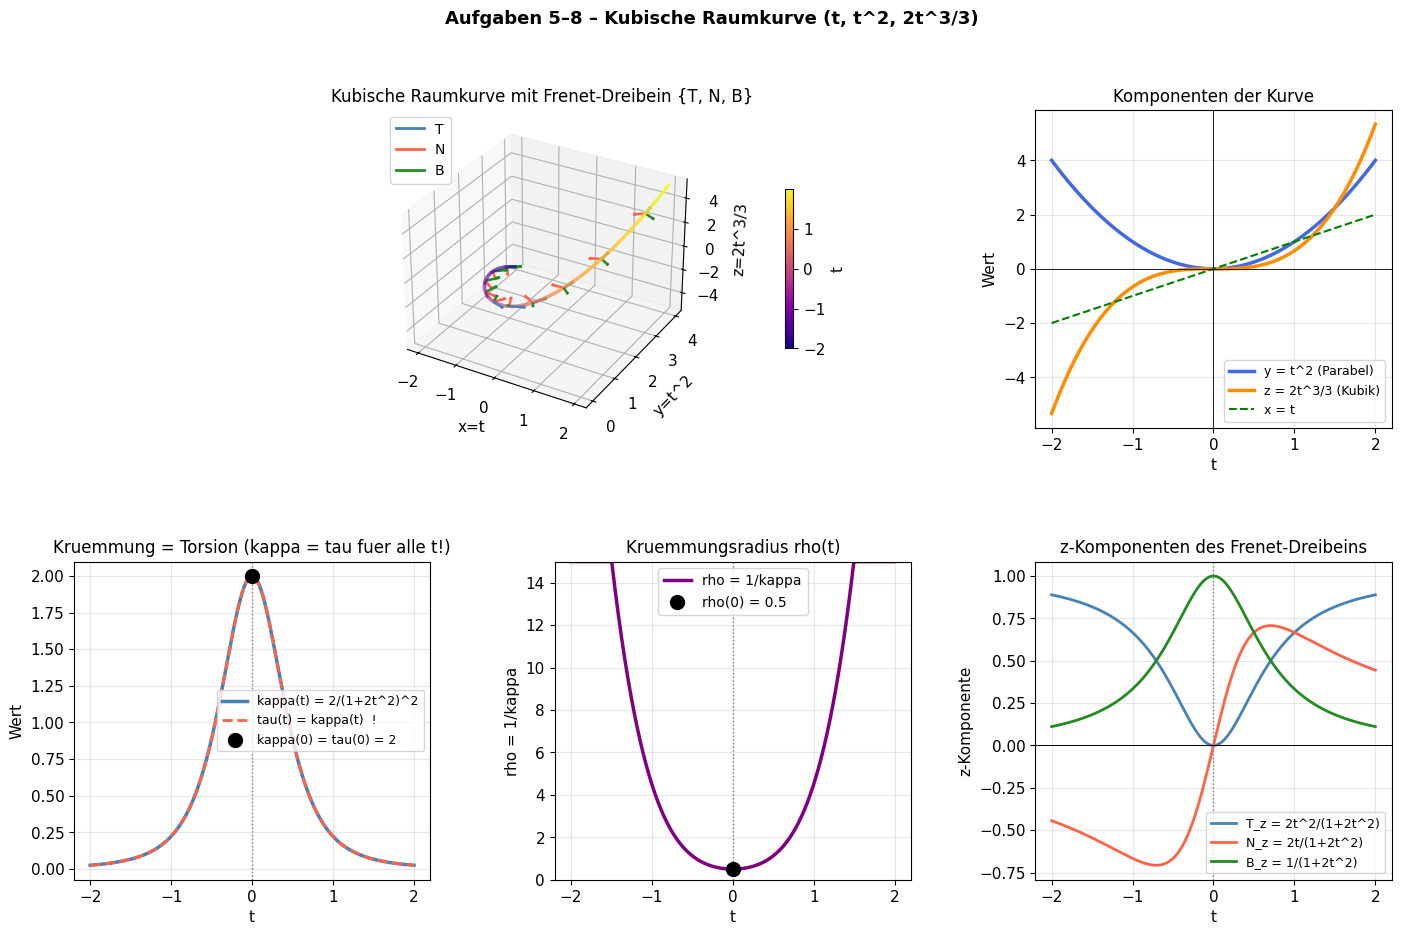

In [9]:
# ── Visualisierung Aufgaben 5–8 ──────────────────────────────────────────────
t_v   = np.linspace(-2, 2, 800)
t_pts = np.linspace(-1.8, 1.8, 10)

X5 = t_v; Y5 = t_v**2; Z5 = 2/3*t_v**3

def frenet5(tp):
    d = 1 + 2*tp**2
    T = np.array([1, 2*tp, 2*tp**2]) / d
    N = np.array([-2*tp, 1-2*tp**2, 2*tp]) / d
    B = np.array([2*tp**2, -2*tp, 1.0]) / d
    return T, N, B

kappa_f = lambda tp: 2/(1+2*tp**2)**2

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel 1: 3D-Kurve mit Dreibein ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0,:2], projection='3d')
pts = np.array([X5,Y5,Z5]).T.reshape(-1,1,3)
segs = np.concatenate([pts[:-1],pts[1:]], axis=1)
lc = Line3DCollection(segs, cmap='plasma', linewidth=2.5)
lc.set_array(t_v[:-1])
ax1.add_collection3d(lc)
sc = 0.35
for tp in t_pts:
    p = np.array([tp, tp**2, 2/3*tp**3])
    T, N, B = frenet5(tp)
    ax1.quiver(*p,*(T*sc), color='steelblue',   arrow_length_ratio=0.25, lw=1.8)
    ax1.quiver(*p,*(N*sc), color='tomato',       arrow_length_ratio=0.25, lw=1.8)
    ax1.quiver(*p,*(B*sc), color='forestgreen',  arrow_length_ratio=0.25, lw=1.8)
handles = [Line2D([0],[0],color='steelblue',  lw=2,label='T'),
           Line2D([0],[0],color='tomato',      lw=2,label='N'),
           Line2D([0],[0],color='forestgreen', lw=2,label='B')]
ax1.legend(handles=handles, fontsize=10, loc='upper left')
ax1.set_xlabel('x=t'); ax1.set_ylabel('y=t^2'); ax1.set_zlabel('z=2t^3/3')
ax1.set_title("Kubische Raumkurve mit Frenet-Dreibein {T, N, B}")
fig.colorbar(lc, ax=ax1, pad=0.1, shrink=0.5, label='t')

# ── Panel 2: Projektionen ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,2])
ax2.plot(t_v, Y5, color='royalblue', lw=2.5, label='y = t^2 (Parabel)')
ax2.plot(t_v, Z5, color='darkorange',lw=2.5, label='z = 2t^3/3 (Kubik)')
ax2.plot(t_v, t_v, color='green',    lw=1.5, ls='--', label='x = t')
ax2.set_xlabel('t'); ax2.set_ylabel('Wert')
ax2.set_title("Komponenten der Kurve")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.axhline(0,color='k',lw=0.6); ax2.axvline(0,color='k',lw=0.6)

# ── Panel 3: kappa = tau ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
kv = kappa_f(t_v)
ax3.plot(t_v, kv, color='steelblue', lw=2.5, label="kappa(t) = 2/(1+2t^2)^2")
ax3.plot(t_v, kv, color='tomato',    lw=2,   ls='--', label="tau(t) = kappa(t)  !")
ax3.scatter([0],[2], color='black', s=100, zorder=5, label='kappa(0) = tau(0) = 2')
ax3.axvline(0, color='gray', lw=1, ls=':')
ax3.set_xlabel('t'); ax3.set_ylabel('Wert')
ax3.set_title("Kruemmung = Torsion (kappa = tau fuer alle t!)")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# ── Panel 4: Kruemmungsradius ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
rho_v = np.clip(1/kv, 0, 15)
ax4.plot(t_v, rho_v, color='purple', lw=2.5, label='rho = 1/kappa')
ax4.scatter([0],[0.5], color='black', s=100, zorder=5, label='rho(0) = 0.5')
ax4.axvline(0, color='gray', lw=1, ls=':')
ax4.set_xlabel('t'); ax4.set_ylabel('rho = 1/kappa')
ax4.set_title("Kruemmungsradius rho(t)")
ax4.legend(fontsize=10); ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 15)

# ── Panel 5: Frenet-Vektor z-Komponenten ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
d_v = 1 + 2*t_v**2
Tz_v =  2*t_v**2 / d_v
Nz_v =  2*t_v    / d_v
Bz_v =  1.0      / d_v
ax5.plot(t_v, Tz_v, color='steelblue',   lw=2, label="T_z = 2t^2/(1+2t^2)")
ax5.plot(t_v, Nz_v, color='tomato',      lw=2, label="N_z = 2t/(1+2t^2)")
ax5.plot(t_v, Bz_v, color='forestgreen', lw=2, label="B_z = 1/(1+2t^2)")
ax5.axhline(0, color='k', lw=0.7)
ax5.axvline(0, color='gray', lw=1, ls=':')
ax5.set_xlabel('t'); ax5.set_ylabel('z-Komponente')
ax5.set_title("z-Komponenten des Frenet-Dreibeins")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

plt.suptitle("Aufgaben 5–8 – Kubische Raumkurve (t, t^2, 2t^3/3)",
             fontsize=13, fontweight='bold')
plt.show()

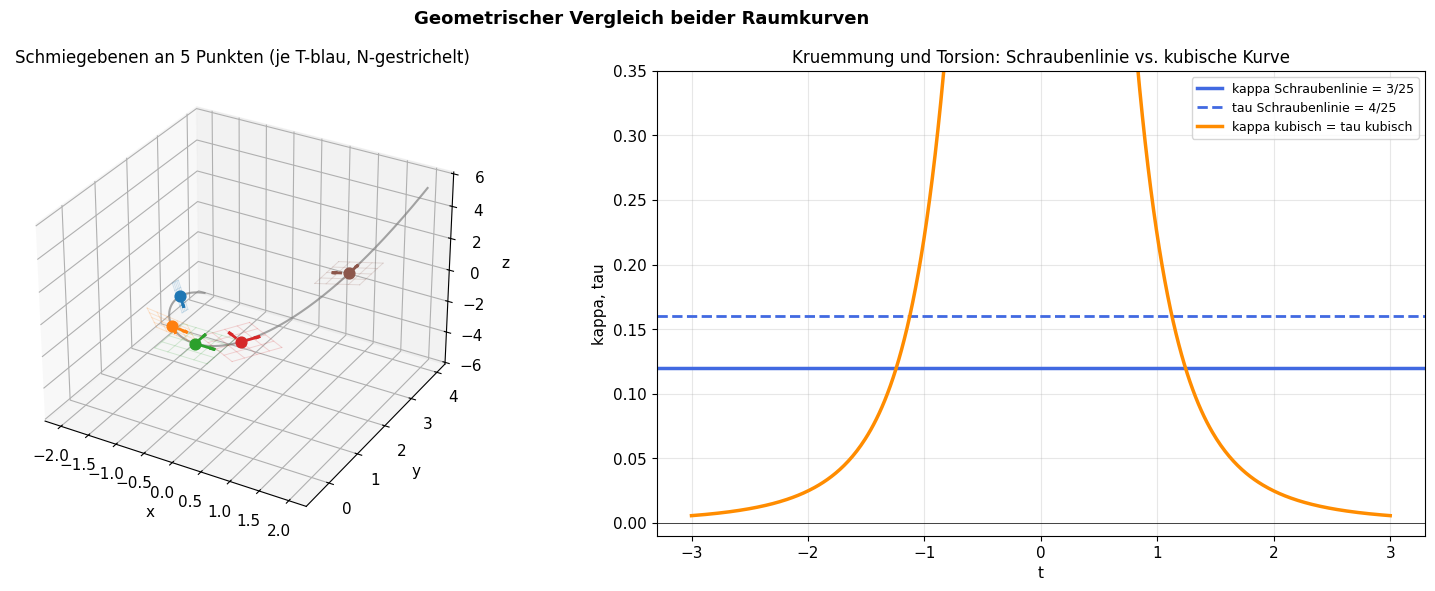

In [10]:
# ── Vergleich beider Kurven: Schmiegebenen ───────────────────────────────────
fig = plt.figure(figsize=(16, 6))

# Links: Schmiegebenen an 5 Punkten auf der kubischen Kurve
ax1 = fig.add_subplot(121, projection='3d')
t_all = np.linspace(-2, 2, 600)
ax1.plot(t_all, t_all**2, 2/3*t_all**3, color='gray', lw=1.5, alpha=0.7)

colors_sp = plt.cm.tab10(np.linspace(0, 0.5, 5))
t_show = [-1.5, -0.6, 0, 0.6, 1.5]
for tp, col in zip(t_show, colors_sp):
    p  = np.array([tp, tp**2, 2/3*tp**3])
    T, N, B = frenet5(tp)
    u_r = np.linspace(-0.45, 0.45, 5)
    for u in u_r:
        pts_l = [p + u*T + v*N for v in u_r]
        xs,ys,zs = zip(*pts_l)
        ax1.plot(xs,ys,zs, color=col, alpha=0.18, lw=0.7)
    for v in u_r:
        pts_l = [p + u*T + v*N for u in u_r]
        xs,ys,zs = zip(*pts_l)
        ax1.plot(xs,ys,zs, color=col, alpha=0.18, lw=0.7)
    ax1.quiver(*p,*(T*0.35), color=col, arrow_length_ratio=0.3, lw=2)
    ax1.quiver(*p,*(N*0.35), color=col, arrow_length_ratio=0.3, lw=2, linestyle='dashed')
    ax1.scatter(*p, color=col, s=60, zorder=5)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("Schmiegebenen an 5 Punkten (je T-blau, N-gestrichelt)")

# Rechts: kappa und tau beider Kurven im Vergleich
ax2 = fig.add_subplot(122)
t_comp = np.linspace(-3, 3, 500)
# Schraubenlinie: kappa=3/25, tau=4/25 (konstant)
ax2.axhline(3/25, color='royalblue',  lw=2.5, label="kappa Schraubenlinie = 3/25")
ax2.axhline(4/25, color='royalblue',  lw=2, ls='--', label="tau Schraubenlinie = 4/25")
# Kubische Kurve
kc = 2/(1+2*t_comp**2)**2
ax2.plot(t_comp, kc, color='darkorange', lw=2.5, label="kappa kubisch = tau kubisch")
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel('t'); ax2.set_ylabel('kappa, tau')
ax2.set_title("Kruemmung und Torsion: Schraubenlinie vs. kubische Kurve")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.01, 0.35)

plt.suptitle("Geometrischer Vergleich beider Raumkurven", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Zusammenfassung

| Aufgabe | Kurve | Ergebnis |
|---------|-------|---------|
| **1** | $(\sin t, \cos t, t)^T$ | $\|df/dt\|=\sqrt{2}$, $\|d^2f/dt^2\|=1$ (beide konstant) |
| **2** | $(e^{-t}, 2\cos3t, 2\sin3t)^T$ | $\|\mathbf{v}(0)\|=\sqrt{37}$, $\|\mathbf{a}(0)\|=5\sqrt{13}$ |
| **3** | Schraubenlinie | $\mathbf{T}=\frac{1}{5}(-3\sin t,3\cos t,4)^T$, $\kappa=\frac{3}{25}$, $\mathbf{N}=(-\cos t,-\sin t,0)^T$ |
| **4** | Schraubenlinie | $\mathbf{B}=\frac{1}{5}(4\sin t,-4\cos t,3)^T$, $\tau=\frac{4}{25}$ |
| **5** | Kubische Kurve | $\mathbf{T}=\frac{1}{1+2t^2}(1,2t,2t^2)^T$ |
| **6** | Kubische Kurve | $\kappa=\frac{2}{(1+2t^2)^2}$, $\mathbf{N}=\frac{1}{1+2t^2}(-2t,1-2t^2,2t)^T$ |
| **7** | Kubische Kurve | $\mathbf{B}=\frac{1}{1+2t^2}(2t^2,-2t,1)^T$ |
| **8** | Kubische Kurve | $\tau=\frac{2}{(1+2t^2)^2}=\kappa$ (Sonderfall: $\kappa=\tau$!) |

### Physikalische Bedeutung
- $\kappa = $ const, $\tau = $ const $\Leftrightarrow$ **reguläre Helix** (Aufgaben 3–4)
- $\kappa = \tau$ für alle $t$ $\Rightarrow$ besondere geometrische Eigenschaft (Aufgaben 5–8)
- $\{\mathbf{T},\mathbf{N},\mathbf{B}\}$ bildet stets ein **rechtshändiges Orthonormalsystem**